In [1]:
eff_acc = {0.0: 0.8733, 0.05: 0.1967, 0.1: 0.1150, 0.15: 0.1167, 0.2: 0.1700}
res_acc = {0.0: 0.9000, 0.05: 0.4683, 0.1: 0.3933, 0.15: 0.3633, 0.2: 0.3783}
swin_acc = {0.0: 0.8933, 0.05: 0.6167, 0.1: 0.5933, 0.15: 0.5733, 0.2: 0.5350}

In [2]:
eff_embed = {0.0: 1.0000, 0.05: 0.1343, 0.1: -0.0030, 0.15: -0.0470, 0.2: -0.0849}
res_embed = {0.0: 1.0000, 0.05: 0.8810, 0.1: 0.8091, 0.15: 0.7657, 0.2: 0.7324}
swin_embed = {0.0: 1.0000, 0.05: 0.9076, 0.1: 0.8311, 0.15: 0.7667, 0.2: 0.7127}

In [3]:
sigmas = [0.0, 0.05, 0.1, 0.15, 0.2]

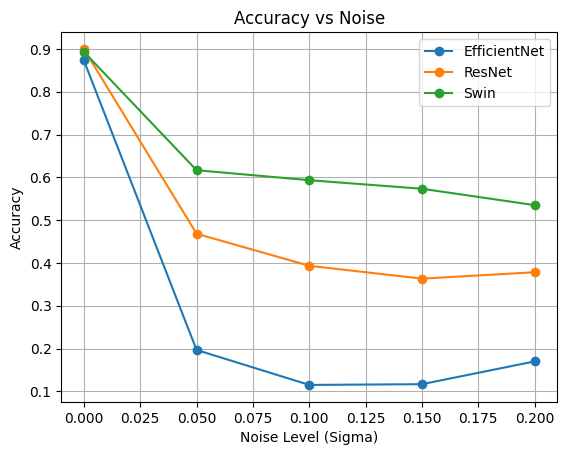

In [4]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(sigmas, list(eff_acc.values()), marker='o', label="EfficientNet")
plt.plot(sigmas, list(res_acc.values()), marker='o', label="ResNet")
plt.plot(sigmas, list(swin_acc.values()), marker='o', label="Swin")

plt.xlabel("Noise Level (Sigma)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Noise")
plt.legend()
plt.grid()

plt.show()

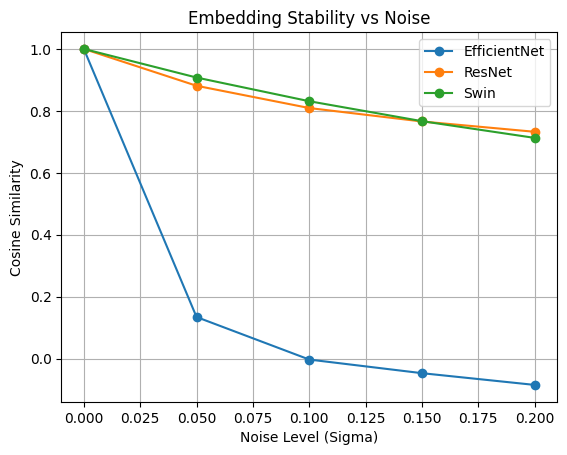

In [5]:
plt.figure()

plt.plot(sigmas, list(eff_embed.values()), marker='o', label="EfficientNet")
plt.plot(sigmas, list(res_embed.values()), marker='o', label="ResNet")
plt.plot(sigmas, list(swin_embed.values()), marker='o', label="Swin")

plt.xlabel("Noise Level (Sigma)")
plt.ylabel("Cosine Similarity")
plt.title("Embedding Stability vs Noise")
plt.legend()
plt.grid()

plt.show()

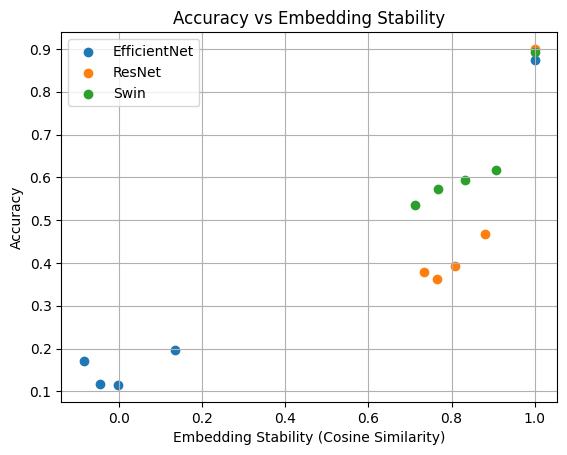

In [6]:
plt.figure()

plt.scatter(list(eff_embed.values()), list(eff_acc.values()), label="EfficientNet")
plt.scatter(list(res_embed.values()), list(res_acc.values()), label="ResNet")
plt.scatter(list(swin_embed.values()), list(swin_acc.values()), label="Swin")

plt.xlabel("Embedding Stability (Cosine Similarity)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Embedding Stability")

plt.legend()
plt.grid()

plt.show()

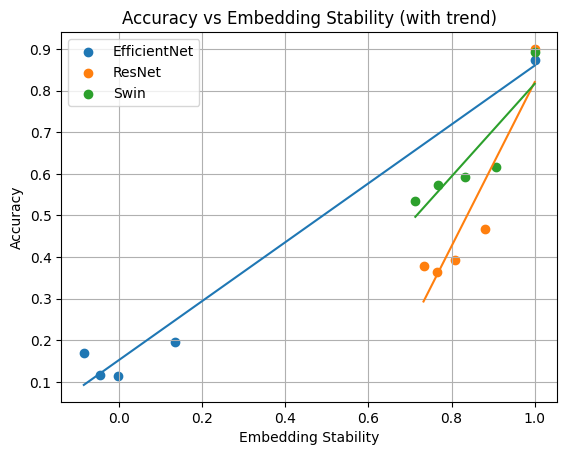

In [12]:
import numpy as np


def plot_with_trend(x, y, label):
    x = np.array(x)
    y = np.array(y)



    plt.scatter(x, y, label=label)

    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)

    plt.plot(x, p(x))

plt.figure()

plot_with_trend(list(eff_embed.values()), list(eff_acc.values()), "EfficientNet")
plot_with_trend(list(res_embed.values()), list(res_acc.values()), "ResNet")
plot_with_trend(list(swin_embed.values()), list(swin_acc.values()), "Swin")

plt.xlabel("Embedding Stability")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Embedding Stability (with trend)")

plt.legend()
plt.grid()

plt.show()

In [8]:


def compute_correlation(embed, acc, name):
    x = np.array(list(embed.values()))
    y = np.array(list(acc.values()))

    corr = np.corrcoef(x, y)[0, 1]
    print(f"{name} Pearson Correlation: {corr:.4f}")
    return corr

compute_correlation(eff_embed, eff_acc, "EfficientNet")
compute_correlation(res_embed, res_acc, "ResNet")
compute_correlation(swin_embed, swin_acc, "Swin")

EfficientNet Pearson Correlation: 0.9881
ResNet Pearson Correlation: 0.9242
Swin Pearson Correlation: 0.8821


np.float64(0.8820651108290912)

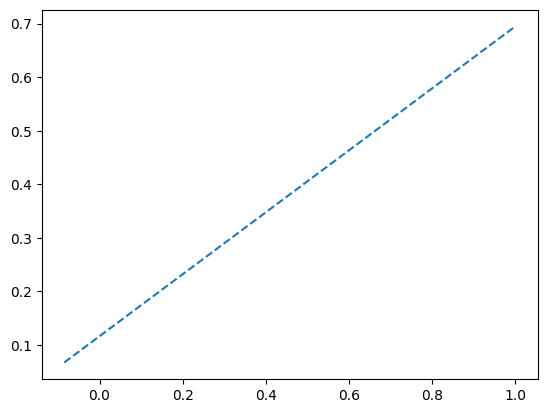

In [13]:
all_embed = list(eff_embed.values()) + list(res_embed.values()) + list(swin_embed.values())
all_acc = list(eff_acc.values()) + list(res_acc.values()) + list(swin_acc.values())

z = np.polyfit(all_embed, all_acc, 1)
p = np.poly1d(z)

x_range = np.linspace(min(all_embed), max(all_embed), 100)
plt.plot(x_range, p(x_range), linestyle='--', label="Global Trend")